# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Read Dataset

In [ ]:
pd.set_option('display.max_columns', None)
data = pd.read_csv('/content/flight.csv')

In [ ]:
data.head(10)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,210,505308,239560.0,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,140,362480,171483.0,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,135,351159,163618.0,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,23,337314,116350.0,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,152,273844,124560.0,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39
5,56972,2/10/2008,9/29/2009,Male,6,guangzhou,guangdong,CN,64.0,3/31/2014,92,313338,112364.0,76946.0,294585,1/13/2014,79,7.043956,52,10,0.967692,343121,15
6,44924,3/22/2006,3/29/2006,Male,6,wulumuqishi,xinjiang,CN,46.0,3/31/2014,101,248864,120500.0,114469.0,287042,3/31/2014,1,7.190000,28,20,0.965347,298873,29
7,22631,4/9/2010,4/9/2010,Female,6,wenzhoushi,zhejiang,CN,50.0,3/31/2014,73,301864,82440.0,114971.0,287230,3/29/2014,3,10.111111,45,7,0.962070,351198,14
8,32197,6/7/2011,7/1/2011,Male,5,DRANCY,NaN,FR,50.0,3/31/2014,56,262958,72596.0,87401.0,321489,3/26/2014,6,13.054545,94,5,0.828478,295158,7
9,31645,7/5/2010,7/5/2010,Female,6,wenzhou,zhejiang,CN,43.0,3/31/2014,64,204855,85258.0,60267.0,375074,3/17/2014,15,11.333333,73,13,0.708010,251907,16


# Data Understanding

| Nama Kolom  | Deskripsi Kolom | Tipe Data Seharusnya  |
|:-----------:|:---------------:|:----------:|
| MEMBER_NO   | ID member       | Integer    |
| FFP_DATE    | Frequent Flyer Program Join Date | Datetime |
| FIRST_FLIGHT_DATE | Tanggal penerbangan pertama | Datetime |
| GENDER      | Jenis Kelamin   | Object |
| FFP_TIER    | Tier dari Frequent Flyer Program | Integer |
| WORK_CITY   | Kota Asal | Object |
| WORK_PROVINCE | Provinsi Asal | Object |
| WORK_COUNTRY | Negara Asal |Object |
| AGE         | Umur Customer | Integer |
| LOAD_TIME   | Tanggal penarikan Data | Datetime |
| FLIGHT_COUNT | Jumlah penerbangan Customer | Integer |
| BP_SUM      | Rencana Perjalanan | Integer |
| SUM_YR_1 | Total Credit / Point Tahun Pertama | Float |
| SUM_YR_2 | Total Credit / Point Tahun Kedua | Float |
| SEG_KM_SUM | Total Jarak (KM) penerbangan yang sudah dilakukan | Integer |
| LAST_FLIGHT_DATE | Tanggal Penerbangan Terakhir | Datetime |
| LAST_TO_END | Jarak waktu penerbangan terakhir ke pesanan penerbangan paling akhir | Integer |
| AVG_INTERNAL | Rata-rata Jarak Waktu | Float |
| MAX_INTERVAL | Maksimal Jarak Waktu | Integer |
| EXCHANGE_COUNT | Jumlah Penukaran | Integer |
| avg_discount  | Rata-rata Discount yang didapat customer | Float |
| Points_Sum | Jumlah Poin yang didapat Customer | Integer |
| Point_NotFlight | Poin yang tidak digunakan oleh member | Integer |

# Analysis Step

Dalam analisis ini, proses dimulai dengan melakukan data preprocessing untuk memastikan dataset siap digunakan, termasuk pengecekan missing values, pemilihan fitur relevan, pembuatan fitur LRFMC, dan normalisasi menggunakan StandardScaler agar seluruh variabel berada pada skala yang sama sebelum dilakukan clustering. Setelah itu dilakukan Exploratory Data Analysis (EDA) untuk memahami distribusi data melalui boxplot, scatterplot antar fitur, serta heatmap korelasi untuk mengidentifikasi pola awal dan potensi outlier. Selanjutnya dilakukan pemodelan K-Means Clustering, dimulai dengan menentukan jumlah cluster optimal menggunakan Elbow Method dan Silhouette Score, yang menunjukkan bahwa k=5 merupakan pilihan paling stabil dan representatif. Model K-Means kemudian dilatih dan hasil clustering divisualisasikan menggunakan scatterplot dan PCA untuk melihat posisi relatif tiap cluster. Setelah cluster terbentuk, dilakukan interpretasi mendalam dengan melihat nilai mean tiap fitur, kategorisasi berdasarkan quartile (Low–Mid–High), dan analisis karakteristik pelanggan pada tiap cluster. Tahap terakhir adalah menyusun insight bisnis dan rekomendasi strategis yang dapat diterapkan perusahaan berdasarkan profil masing-masing segmen pelanggan.

# Preprocessing

Pada tahap ini, beberapa proses dilakukan untuk menyiapkan dataset sebelum digunakan dalam model clustering. Preprocessing yang baik memastikan data bersih, konsisten, dan siap dianalisis.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [ ]:
data.columns

Index(['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER',
       'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME',
       'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM',
       'LAST_FLIGHT_DATE', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL',
       'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight'],
      dtype='object')

In [ ]:
data.isna().sum()

,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2269
WORK_PROVINCE,3248
WORK_COUNTRY,26
AGE,420
LOAD_TIME,0


Terdapat sebanyak:
- 3 Missing Values pada kolom GENDER
- 2269 Missing Values pada kolom WORK_CITY
- 3248 Missing Values pada kolom WORK_PROVINCE
- 26 Missing Values pada kolom WORK_COUNTRY
- 420 Missing Values pada kolom AGE
- 551 Missing Values pada kolom SUM_YR_1
- 138 Missing Values pada kolom SUM_YR_2

## Correct Column Names

In [ ]:
data.columns = data.columns.str.lower().str.replace(' ', '_')

In [ ]:
data.columns

Index(['member_no', 'ffp_date', 'first_flight_date', 'gender', 'ffp_tier',
       'work_city', 'work_province', 'work_country', 'age', 'load_time',
       'flight_count', 'bp_sum', 'sum_yr_1', 'sum_yr_2', 'seg_km_sum',
       'last_flight_date', 'last_to_end', 'avg_interval', 'max_interval',
       'exchange_count', 'avg_discount', 'points_sum', 'point_notflight'],
      dtype='object')

Nama Kolom sudah dikoreksi

## Correct Data Types

In [ ]:
# Ubah kolom yang mengandung tanggal / date menjadi datetime
date_cols = ['ffp_date','first_flight_date','last_flight_date','load_time']

for col in date_cols:
  if col in data.columns:
    data[col] = pd.to_datetime(data[col], errors='coerce', format='mixed')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   member_no          62988 non-null  int64         
 1   ffp_date           62988 non-null  datetime64[ns]
 2   first_flight_date  62988 non-null  datetime64[ns]
 3   gender             62985 non-null  object        
 4   ffp_tier           62988 non-null  int64         
 5   work_city          60719 non-null  object        
 6   work_province      59740 non-null  object        
 7   work_country       62962 non-null  object        
 8   age                62568 non-null  float64       
 9   load_time          62988 non-null  datetime64[ns]
 10  flight_count       62988 non-null  int64         
 11  bp_sum             62988 non-null  int64         
 12  sum_yr_1           62437 non-null  float64       
 13  sum_yr_2           62850 non-null  float64       
 14  seg_km

## Check Missing Values

In [ ]:
# Buat Fungsi untuk menghitung persentase Missing Values
def missing_percentage(data):
  missing = data.isnull().sum()
  percent = (missing / len(data))*100
  result = pd.DataFrame({
      'Missing Count': missing,
      'Percentage (%)': percent.round(2)
  })
  return result.sort_values('Percentage (%)', ascending=False)

In [ ]:
missing_percentage(data)

,Missing Count,Percentage (%)
work_province,3248,5.16
work_city,2269,3.60
sum_yr_1,551,0.87
age,420,0.67
last_flight_date,421,0.67
sum_yr_2,138,0.22
work_country,26,0.04
gender,3,0.00
ffp_tier,0,0.00
ffp_date,0,0.00


## Drop Irrelevant Columns

Drop kolom yang tidak relevan dengan tujuan project, yaitu menganalisis perilaku pelanggan berdasarkan   
data perjalanan (Travel Behaviour)

| Daftar Kolom yang perlu di drop  | Alasan mengapa mendrop kolom |
|:--------------------------------:|:----------------------------:|
| member_no | merupakan Identifier dan tidak mempengaruhi Travel Behaviour |
| gender    | merupakan atribut identifier, tidak ada hubungan dengan Travel Behaviour, maskapai tidak mengelompokkan perilaku konsumen berdasarkan gender |
| work_city | merupakan fitur demografi, bukan perilaku |
| work_province | merupakan fitur demografi, bukan perilaku |
| work_country | merupakan fitur demografi, bukan perilaku |  

In [ ]:
def drop_irrelevant_col(data):
  cols_to_drop = [
      'member_no',
      'gender',
      'work_city',
      'work_province',
      'work_country',
  ]
  return data.drop(columns = [col for col in cols_to_drop if col in data.columns])

In [ ]:
df = drop_irrelevant_col(data)

In [ ]:
df.head()

,ffp_date,first_flight_date,ffp_tier,age,load_time,flight_count,bp_sum,sum_yr_1,sum_yr_2,seg_km_sum,last_flight_date,last_to_end,avg_interval,max_interval,exchange_count,avg_discount,points_sum,point_notflight
0,2006-11-02,2008-12-24,6,31.0,2014-03-31,210,505308,239560.0,234188.0,580717,2014-03-31,1,3.483254,18,34,0.961639,619760,50
1,2007-02-19,2007-08-03,6,42.0,2014-03-31,140,362480,171483.0,167434.0,293678,2014-03-25,7,5.194245,17,29,1.252314,415768,33
2,2007-02-01,2007-08-30,6,40.0,2014-03-31,135,351159,163618.0,164982.0,283712,2014-03-21,11,5.298507,18,20,1.254676,406361,26
3,2008-08-22,2008-08-23,5,64.0,2014-03-31,23,337314,116350.0,125500.0,281336,2013-12-26,97,27.863636,73,11,1.090870,372204,12
4,2009-04-10,2009-04-15,6,48.0,2014-03-31,152,273844,124560.0,130702.0,309928,2014-03-27,5,4.788079,47,27,0.970658,338813,39


Pisahkan kolom numerical dan kategorikal pada suatu variable

In [ ]:
numerical_col = df.select_dtypes(include=['int64','float64']).columns

In [ ]:
numerical_col

Index(['ffp_tier', 'age', 'flight_count', 'bp_sum', 'sum_yr_1', 'sum_yr_2',
       'seg_km_sum', 'last_to_end', 'avg_interval', 'max_interval',
       'exchange_count', 'avg_discount', 'points_sum', 'point_notflight'],
      dtype='object')

## Handle Missing Values

In [ ]:
df.isna().sum()

,0
ffp_date,0
first_flight_date,0
ffp_tier,0
age,420
load_time,0
flight_count,0
bp_sum,0
sum_yr_1,551
sum_yr_2,138
seg_km_sum,0


In [ ]:
missing_percentage(df)

,Missing Count,Percentage (%)
sum_yr_1,551,0.87
age,420,0.67
last_flight_date,421,0.67
sum_yr_2,138,0.22
first_flight_date,0,0.00
ffp_date,0,0.00
flight_count,0,0.00
load_time,0,0.00
bp_sum,0,0.00
ffp_tier,0,0.00


In [ ]:
# Fill Missing Values for each column with median
imputer = SimpleImputer(strategy='median')
df[numerical_col] = imputer.fit_transform(df[numerical_col])

### Check Missing Values

In [ ]:
missing_percentage(df)

,Missing Count,Percentage (%)
last_flight_date,421,0.67
ffp_date,0,0.00
first_flight_date,0,0.00
ffp_tier,0,0.00
load_time,0,0.00
age,0,0.00
bp_sum,0,0.00
sum_yr_1,0,0.00
sum_yr_2,0,0.00
flight_count,0,0.00


Masih terdapat 421 Missing values pada kolom `last_flight_date' atau sekitar 0.67%, namun karena nanti fitur yang dipakai adalah kolom L,R,M,F,C , yang tidak bergantung pada last_flight_date secara langsung (karena recency dihitung dari last_to_end, bukan dari date raw)  

Oleh karena itu:
- Missing values tidak diimputasi
- kolom-kolom tanggal lama dibuang setelah LRFMC dibuat
- karena tidak digunakan sebagai fitur model

# Feature Engineering

Modifikasi kolom untuk model hanya menjadi 5 Fitur yaitu L,R,M,F,C:

| Fitur | Arti | Rumus |
|:-----:|:----:|:-----:|
| L(Loyalty / Length) | Lama jadi member | load_time - ffp_date |
| R(Recency) | Hari sejak terakhir terbang | last_to_end |
| F(Frequency) | Frekuensi Terbang | flight_count |
| M(Monetary) | Total jarak tempuh | seg_km_sum |
| C(Discount Ratio) | Tingkat penggunaan diskon | avg_discount |

In [ ]:
df['l'] = (df['load_time'] - df['ffp_date']).dt.days
df['r'] = df['last_to_end']
df['f'] = df['flight_count']
df['m'] = df['seg_km_sum']
df['c'] = df['avg_discount']

**Mengapa LRFMC?**  
Model LRFMC adalah sandar industri airline (China Shoutern, Emirates, SAS)  
Merangkum perilaku pelanggan dalam 5 dimensi inti:  
- Loyalty / Length (L)
- Recency (R)
- Frequency (F)
- Monetary (M)
- Discount (C)

Fitur dalam LRFMC stabil, tidak redundant, dan sangat cocok untuk segmentasi

# Exploratory Data Analysis (EDA)

Filter kolom yang hanya akan digunakan untuk clustering customer maskapai, yaitu (L,R,M,F,C), dan exclude kolom original seperti:
- ffp_date
- first_flight_date
- last_flight_date
- points_sum dan point_notflight
- interval
- tanggal mentah lain

dilakukan filtering karena:
1. Tidak diperlukan untuk clustering
2. redundant terhadap fitur LRFMC
3. Menambah noise bila dimasukan
4. Membuat hasil cluster menjadi tidak stabil

In [ ]:
features = ['l','r','f','m','c']
df_lrfmc = df[features].copy()
df_lrfmc.head()

,l,r,f,m,c
0,2706,1.0,210.0,580717.0,0.961639
1,2597,7.0,140.0,293678.0,1.252314
2,2615,11.0,135.0,283712.0,1.254676
3,2047,97.0,23.0,281336.0,1.090870
4,1816,5.0,152.0,309928.0,0.970658


In [ ]:
df_lrfmc.describe()

,l,r,f,m,c
count,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000
mean,1485.000826,176.120102,11.839414,17123.878691,0.721558
std,847.222941,183.822223,14.049471,20960.844623,0.185427
min,365.000000,1.000000,2.000000,368.000000,0.000000
25%,732.000000,29.000000,3.000000,4747.000000,0.611997
50%,1270.000000,108.000000,7.000000,9994.000000,0.711856
75%,2179.000000,268.000000,15.000000,21271.250000,0.809476
max,3437.000000,731.000000,213.000000,580717.000000,1.500000


### Histplot

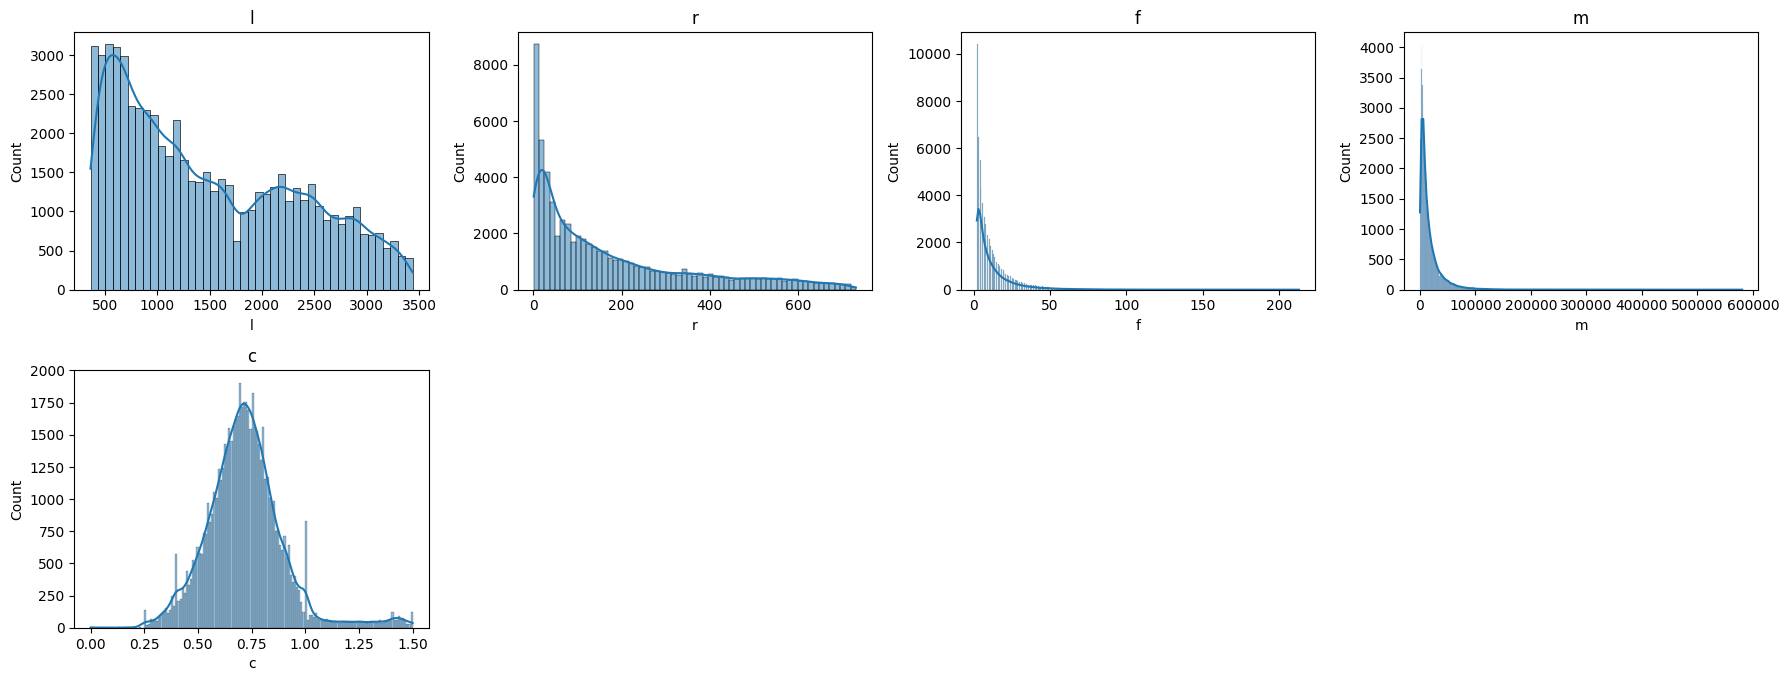

In [ ]:
plt.figure(figsize=(18,20))
for i, col in enumerate(df_lrfmc.columns):
  plt.subplot(6, 4, i+1)
  sns.histplot(df[col], kde=True)
  plt.title(col)
plt.tight_layout()
plt.show()

### Insight EDA Histplot

#### L - Loyalty (FFP Length)

- Distribusi right-skewed - mayoritas pelanggan baru bergabung dalam 500 - 2000 hari terakhir  
- Ada beberapa pelanggan yang sudah menjadi member hingga 3000+ hari
- Sebagian besar pelanggan adalah member baru atau menengah, dan hanya sebagian kecil yang benar benar member lama

#### R - Recency (Last to End)

 - Distribusi sangat right_skewed - mayoritas pelanggan baru melakukan penerbangan 0-100 hari terakhir  
 - Ada kelompok dengan recency tinggi (>400 hari) ini adalah pelanggan dorman / hampir churn  
 - Base pelanggan airline masih cukup aktif, namun tetap ada risiko churn

#### F - Flight Frequency

- Highly Right - Skewed , sebagian besar pelanggan hanya terbang 1-10 kali
- terdapat sedikit pelanggan super-frequent flyers yang melakukan >50-200 flights, mereka adalah kelompok prioritas bernilai tinggi  
- Distribusi ini menunjukkan sifat umum layanan maskapai, banyak pelanggan casual, dan sedikit pelanggan loyal (premium)

#### M - Monetary (Travel Distance)

- Distribusi sangat Right-skewed, mayoritas pelanggan hanya melakukan penerbangan jarak dekat.
- Namun ada outlier eksrtrim dengan total km hingga > 500.000 km, yang menunjukkan kelompok high value long haul travelers.
- Fitur ini memisahkan jelas pelanggan bernilai tinggi vs pelanggan low-value

#### C - Average Discount

- Distribusi hampir normal dengan mean , di sekitar 0.5-0.7
- Kebanyakan pelanggan mendapatkan diskon moderat
- Fitur ini bisa memisahkan price-sensitive vs full-fare customers

#### Kesimpulan LRFMC

- Skewed distributions pada L, R, F, M menunjukkan banyak pelanggan “casual” dan hanya sedikit high-value customers.

- Cluster pelanggan sangat mungkin terbentuk dari kontradiksi F & M (value), serta R (aktivitas terbaru).

- Fitur C (discount) dapat membantu memisahkan kelompok sensitif harga vs non-sensitif.

- Struktur dataset ini sangat cocok untuk segmentasi menggunakan K-Means karena perbedaan perilaku sudah terlihat jelas dari histogram.

## Heatmap

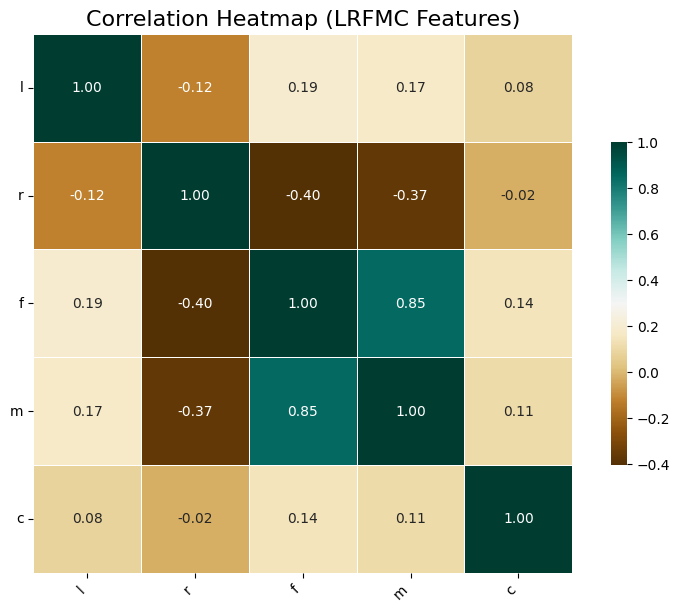

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(
    df_lrfmc.corr(),
    cmap='BrBG',
    annot=True,        # <<< ini penting biar terlihat angka korelasinya
    fmt=".2f",
    linewidths=.5,
    square=True,
    cbar_kws={"shrink": .6}
)
plt.title("Correlation Heatmap (LRFMC Features)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


#### Insight Heatmap

###  Kesimpulan Analisis Korelasi

Berdasarkan heatmap korelasi, terdapat beberapa pola penting:

F dan M memiliki korelasi sangat tinggi (0.85), menunjukan hubungan kuat antara frekuensi terbang dan total jarak tempuh. R berkorelasi negatif dengan F dan M, menandakan pelanggan tidak aktif memiliki nilai rendah. L dan C memiliki korelasi kecil terhadap fitur lain.


## Scaterplot

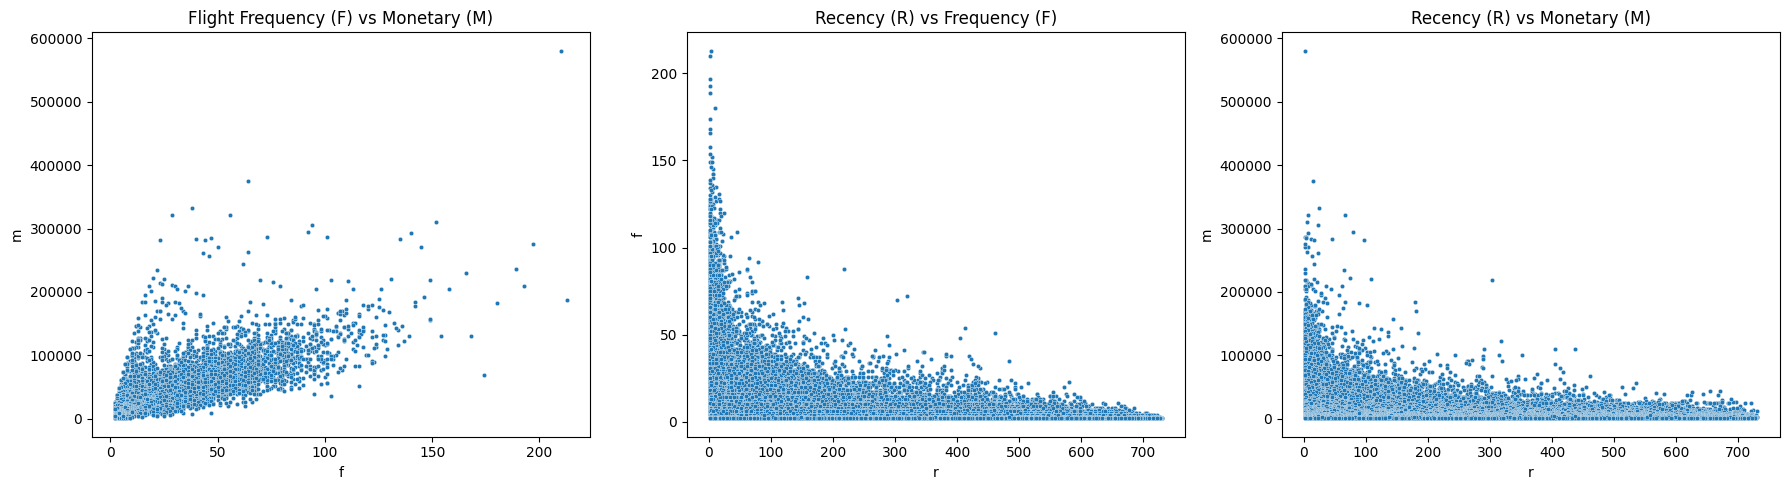

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x='f', y='m', data=df_lrfmc, ax=axs[0],
    s=10
)
axs[0].set_title('Flight Frequency (F) vs Monetary (M)')

sns.scatterplot(
    x='r', y='f', data=df_lrfmc, ax=axs[1],
    s=10
)
axs[1].set_title('Recency (R) vs Frequency (F)')

sns.scatterplot(
    x='r', y='m', data=df_lrfmc, ax=axs[2],
    s=10
)
axs[2].set_title('Recency (R) vs Monetary (M)')

plt.tight_layout()
plt.show()


Flight Frequency (F) vs Monetary (M):

Scatterplot ini menunjukkan hubungan positif yang sangat kuat, sesuai dengan korelasi tinggi (0.85) pada heatmap.

Interpretasi:
- Semakin sering pelanggan melakukan penerbangan (F Tinggi), semakin besar jarak total tempuh atau biaya penerbangan dicatat (M Tinggi).
- Terdapat pesebaran data yang melebar ke atas seiring meningkatnya F, menandakan high-frequency memiliki kontribusi revenue yang signifikan.

Insight Bisnis:  
Pelanggan dengan frekuensi penerbangan tinggi adalah kontributor revenue utama dan cocok untuk program loyalitas premium

Recency (R) vs Frequency (F)  
Scatterplot ini menunjukkan hubungan negatif yang cukup kuat (-0.40)  

Interpretasi:  
- Pelanggan dengan nilai R kecil (baru baru ini melakukan penerbangan) cenderung memiliki frekuensi penerbangan lebih tinggi.
- semakin tinggi nilai R (semakin lama tidak melakukan penerbangan), nilai F turun mendekati nol  
- Pelanggan aktif mudah dikenali dengan kombinasi R rendah & F tinggi  

Insight Bisnis:  
Pelanggan dengan R tinggi (tidak aktif melakukan penerbangan) perlu ditargetkan kampanye reaktivasi, misalnya promo rute tertentu

Recency (R) vs Monetary (M)  
Scatterplot ini juga menunjukkan hubungan negatif moderat (-0.37) pada heatmap  

Interpretasi:  
- Pelanggan yang sudah lama tidak terbang (R Tinggi) memiliki nilai M yang rendah → jarang membeli tiket jarak jauh atau jarang terbang sama sekali  
- Kelompok pelanggan high-value berada pada area R rendah dan M tinggi  

Insight Bisnis:  
Pelanggan dengan R rendah dan M tinggi merupakan top-tier customer (VIP segment)

## Boxplot

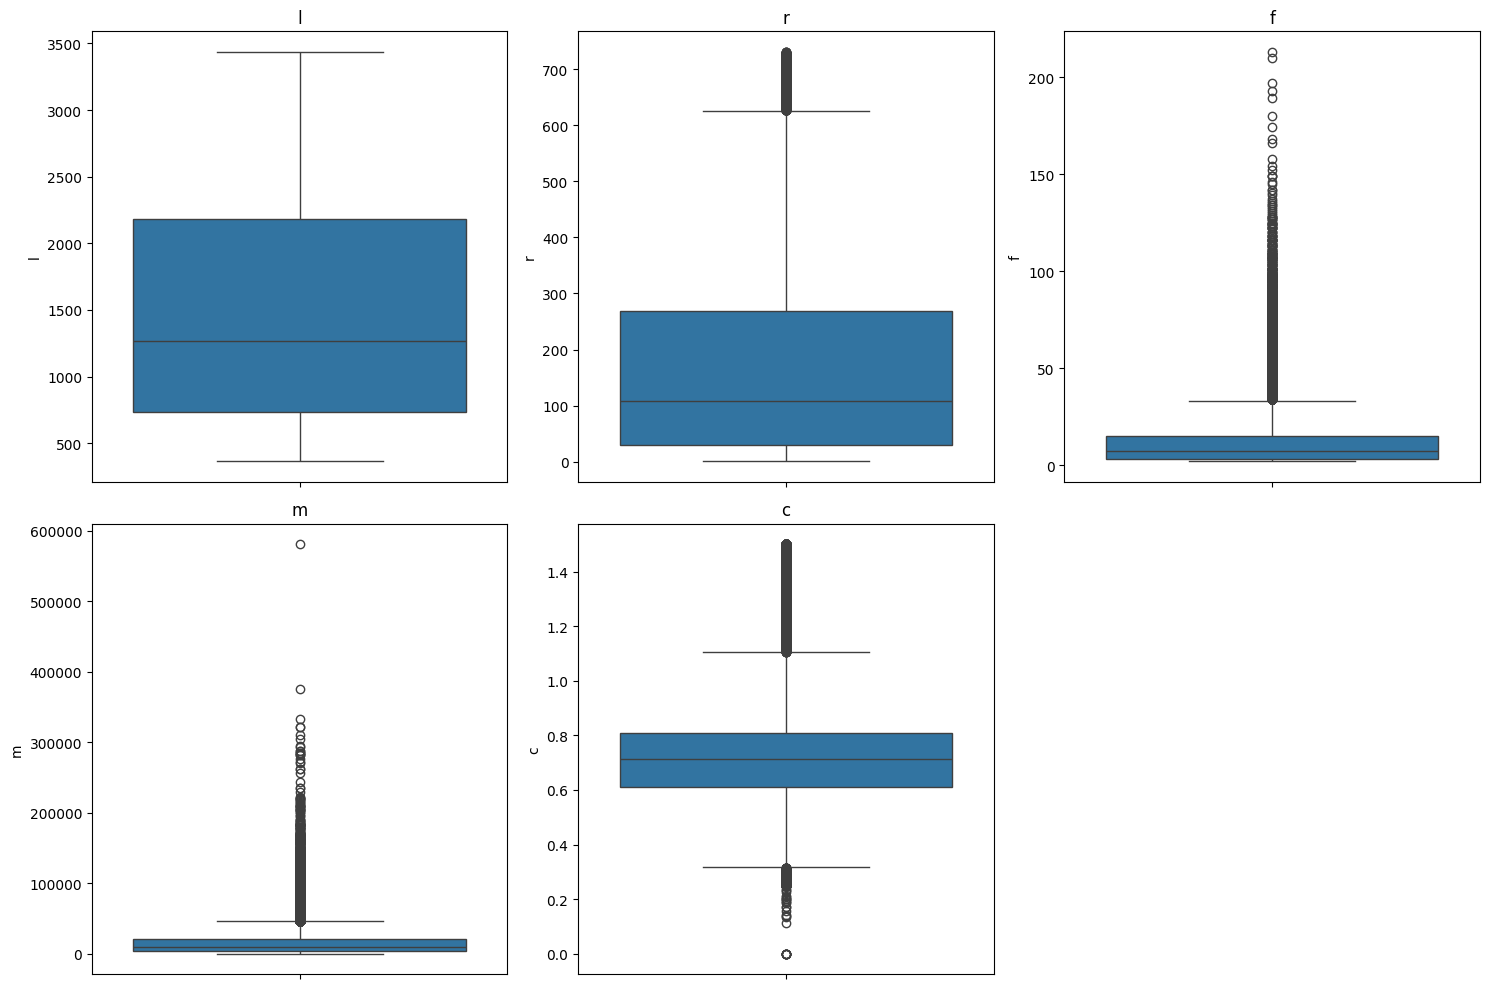

In [ ]:
cols = ['l', 'r', 'f', 'm', 'c']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_lrfmc[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Terdapat banyak outlier pada setiap kolom l,r,f,m,c sehingga harus di remove terlebih dahulu sebelum masuk ke K-Means

In [ ]:
# Remove outlier dengan metode IQR untuk tiap kolom L, R, F, M, C

Q1 = df_lrfmc.quantile(0.25)
Q3 = df_lrfmc.quantile(0.75)
IQR = Q3 - Q1

df_lrfmc_no_outlier = df_lrfmc[
    ~(
        (df_lrfmc < (Q1 - 1.5 * IQR)) |
        (df_lrfmc > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

print("Before removing outliers:", df_lrfmc.shape)
print("After removing outliers :", df_lrfmc_no_outlier.shape)


Before removing outliers: (62988, 5)
After removing outliers : (53181, 5)


# Clustering Techniques

## Scaled dataset used for model

Sebelum melakukan clustering, data LRFMC perlu di normalisasi menggunakan StandardScaler.  
Hal ini penting karena K-Means sensitif terhadap perbedaan skala antar fitur

In [ ]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_lrfmc_no_outlier)
scaled_df_lrfmc = pd.DataFrame(scaled_array, columns=df_lrfmc_no_outlier.columns)

## K-Means

### Define Optimum Cluster

### Elbow Method

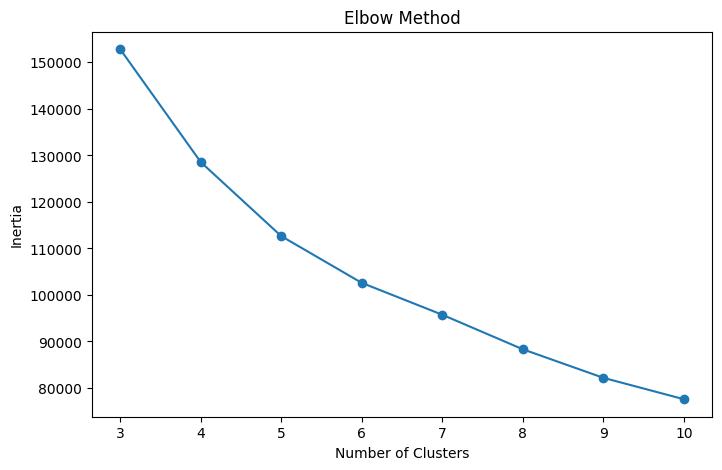

In [ ]:
inertia = []
K = range(3, 11)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_df_lrfmc)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Berdasarkan grafik elbow method di atas, terlihat bahwa inertia terus menurun secara mulus tanpa adanya titik tekukan (elbow) yang jelas.  

Penurunan inertia dari K=3  hingga K=10 bersifat gradual dan stabil, sehingga tidak ada perubahan tajam yang dapat dijadikan acuan jumlah cluster optimal

Pola penurunan yang terlihat:
- K = 3 → 4 → 5 terjadi penurunan cukup besar
- K = 5 → 6 → 7 → 8 → 9 → 10 Penurunan semakin kecil dan stabil

Hal ini menunjukan bahwa:
- Tidak ada titik elbow yang jelas
- K-Means tidak menunjukan titik optimal alami berdasarkan inertia
- Elbow method tidak cukup untuk menentukan jumlah cluster terbaik

Kesimpulan:
- Karena grafik inertia tidak menunjukkan elbow yang tegas, maka pemilihan jumlah cluster harus menggunakan metrik lain, yaitu **Silhouette Score** , agar hasil yang dipilih lebih objektif dan representatif

### Silhouette Score

Cluster = 3, Silhouette Score = 0.2363
Cluster = 4, Silhouette Score = 0.2444
Cluster = 5, Silhouette Score = 0.2353
Cluster = 6, Silhouette Score = 0.2217
Cluster = 7, Silhouette Score = 0.2191
Cluster = 8, Silhouette Score = 0.2107
Cluster = 9, Silhouette Score = 0.2133
Cluster = 10, Silhouette Score = 0.2168


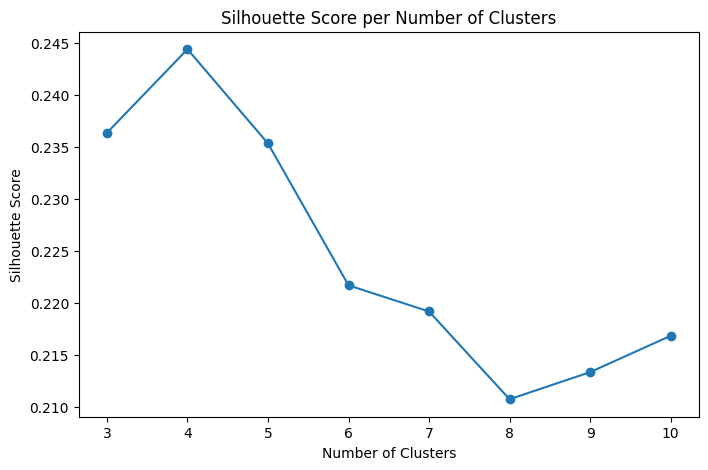

In [ ]:
sil_scores = {}
k = range(3, 11)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(scaled_df_lrfmc)
  sil = silhouette_score(scaled_df_lrfmc, labels)
  sil_scores[k] = sil
  print(f"Cluster = {k}, Silhouette Score = {sil:.4f}")

plt.figure(figsize=(8,5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.title('Silhouette Score per Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Berdasarkan hasil perhitungan Silhouette Score dengan cluster 3-10, nilai tertinggi berada pada 4 cluster (0.2444). Hal ini menunjukan bahwa 4 cluster memberikan struktur pemisahan yang paling baik dibandingkan cluser lain

### Train K-Means Final Model

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_df_lrfmc)

In [ ]:
df_insight = df_lrfmc_no_outlier.copy()
df_insight['cluster'] = cluster_labels

### PCA for 2D Visualization

In [ ]:
pca = PCA(n_components=2)
pca_comp = pca.fit_transform(scaled_df_lrfmc)

df_plot = df_insight.copy()
df_plot['pca1'] = pca_comp[:, 0]
df_plot['pca2'] = pca_comp[:, 1]

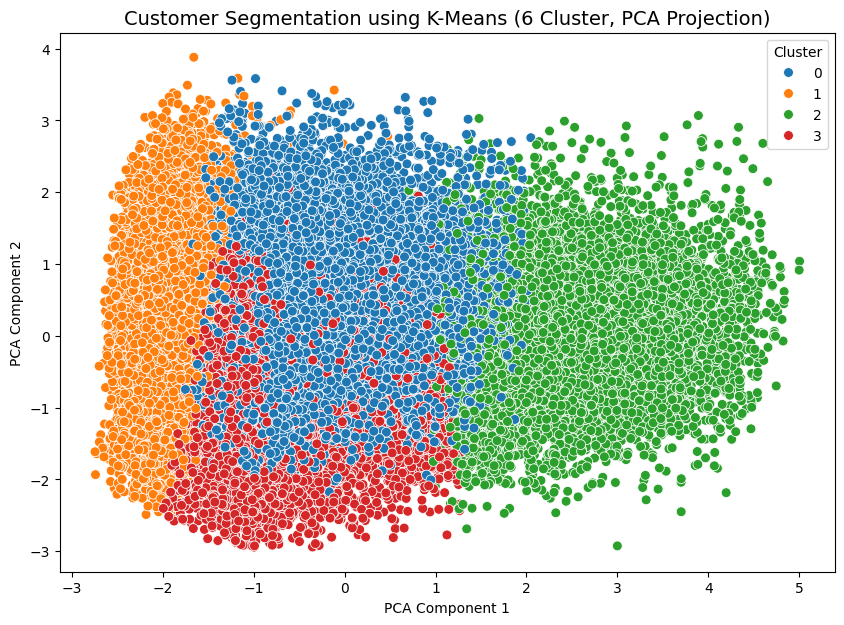

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_plot,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='tab10',
    s=50
)
plt.title("Customer Segmentation using K-Means (6 Cluster, PCA Projection)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()


In [ ]:
df_insight.groupby('cluster').mean().T

cluster,0,1,2,3
l,2449.739180,1172.385363,1608.212999,865.567390
r,130.005246,441.849941,63.881044,110.095451
f,6.665492,3.781619,19.892903,6.508950
m,9416.217131,5673.161851,27801.004505,9219.873118
c,0.706106,0.718023,0.721072,0.672018


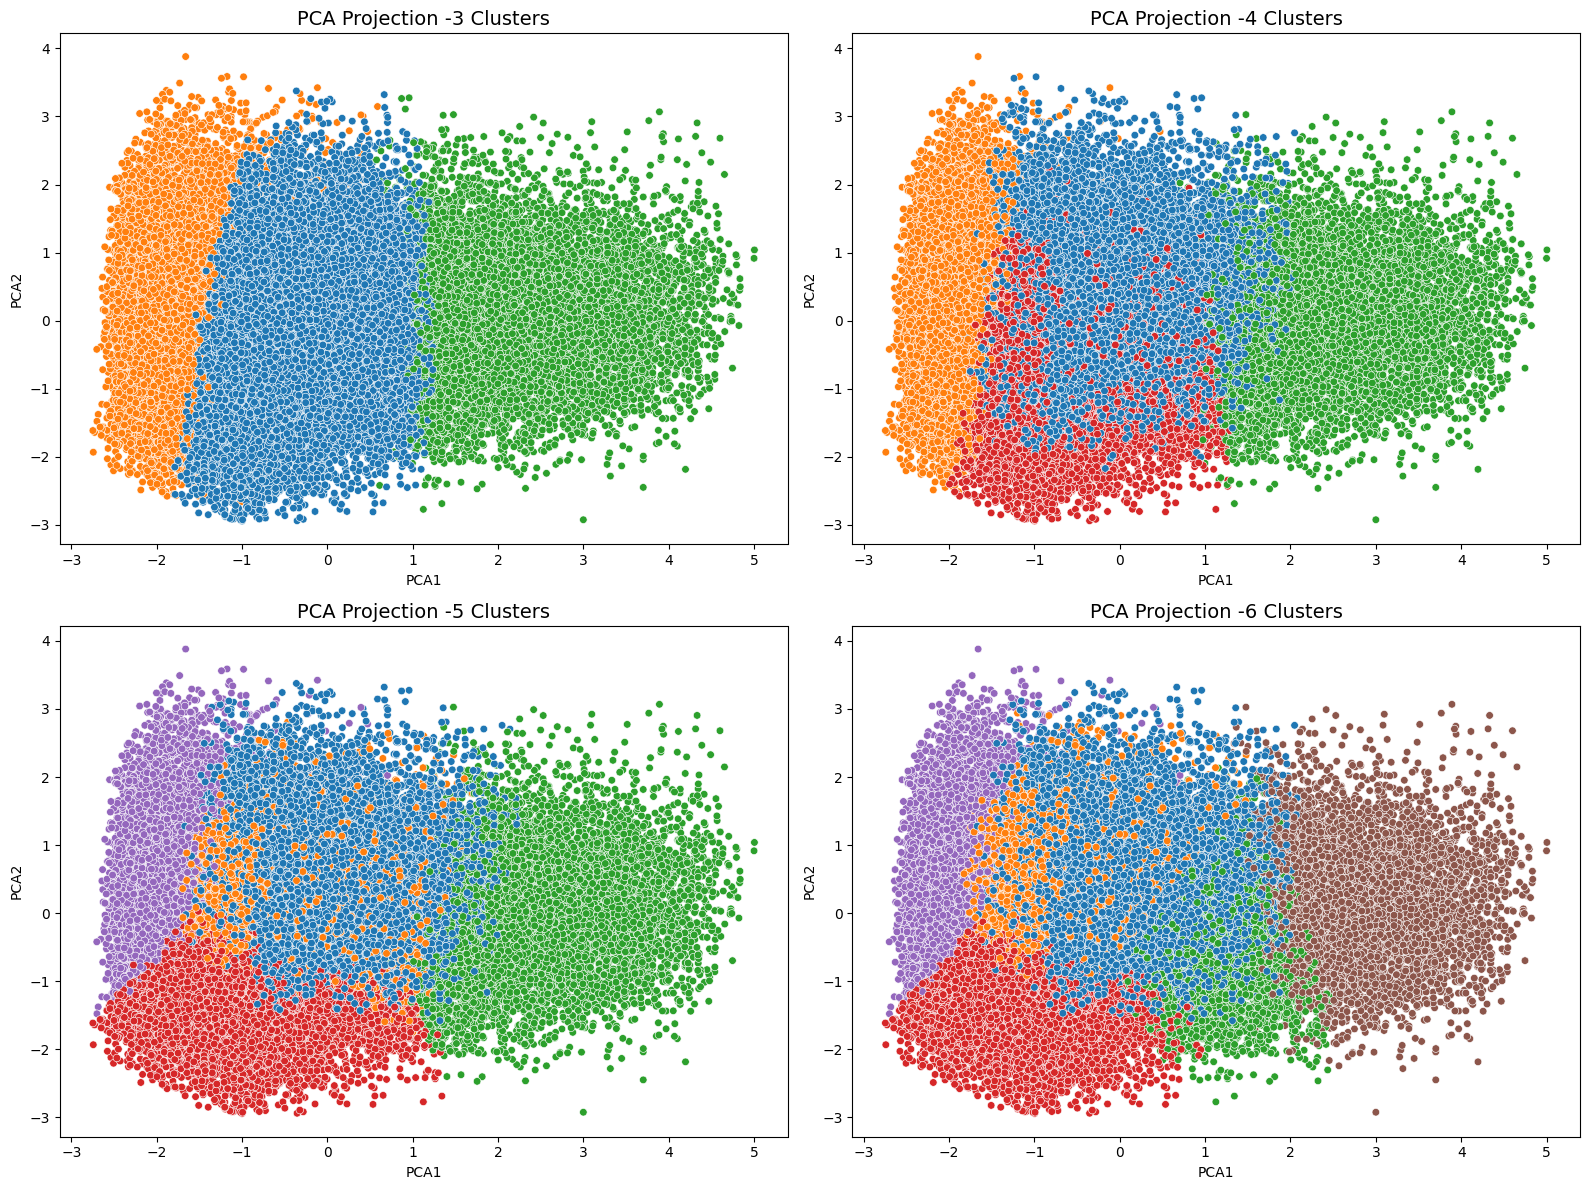

In [ ]:
cluster_list = [3,4,5,6]
pca = PCA(n_components=2)
pca_comp = pca.fit_transform(scaled_df_lrfmc)

df_pca = df_lrfmc_no_outlier.copy()
df_pca['pca1'] = pca_comp[:, 0]
df_pca['pca2'] = pca_comp[:, 1]

plt.figure(figsize=(16,12))

for i, k in enumerate(cluster_list, 1):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(scaled_df_lrfmc)

  df_pca['cluster'] = labels

  plt.subplot(2, 2, i)
  sns.scatterplot(
      data=df_pca,
      x='pca1',
      y='pca2',
      hue='cluster',
      palette='tab10',
      s=30,
      legend=False
  )
  plt.title(f"PCA Projection -{k} Clusters", fontsize=14)
  plt.xlabel("PCA1")
  plt.ylabel("PCA2")

plt.tight_layout()
plt.show()

### Insight PCA Viz

- Metode Matematis (Silhouette Score) Cluster optimal = 4
- Interpretasi visual (PCA) cluster paling stabil = 4 atau 5
- Pertimbangan Industri, Cluster terbaik adalah 5 cluster

Berdasarkan evaluasi Silhouette Score, jumlah cluster dengan performa terbaik adalah K=4. Namun berdasarkan analisis visual PCA serta pertimbangan praktik industri maskapai, konfigurasi 5 cluster merupakan segmentasi paling stabil, interpretatif dan actionable untuk kebutuhan bisnis, karena dari cluster 5 ke 6 perbedaan hanya sedikit (tidak signifikan) yang menunjukkan gejala over-clustering / overfitting

### Choosen Cluster

Cluster terbaik yang terpilih adalah jumlah cluster = 5

Silhouette Score (k=5): 0.2358

Cluster Counts:


,count
cluster,
0,9680
1,10826
2,10088
3,13969
4,8618



Cluster Means (LRFMC):


cluster,0,1,2,3,4
l,1034.576550,2515.786717,1617.163164,895.285060,1250.265491
r,199.852789,123.866248,61.913759,102.864342,457.597702
f,4.611260,7.064013,20.313640,7.456296,3.847993
m,7136.981302,9992.528727,28475.964116,10158.627246,5686.483639
c,0.508719,0.711702,0.713312,0.765335,0.775470


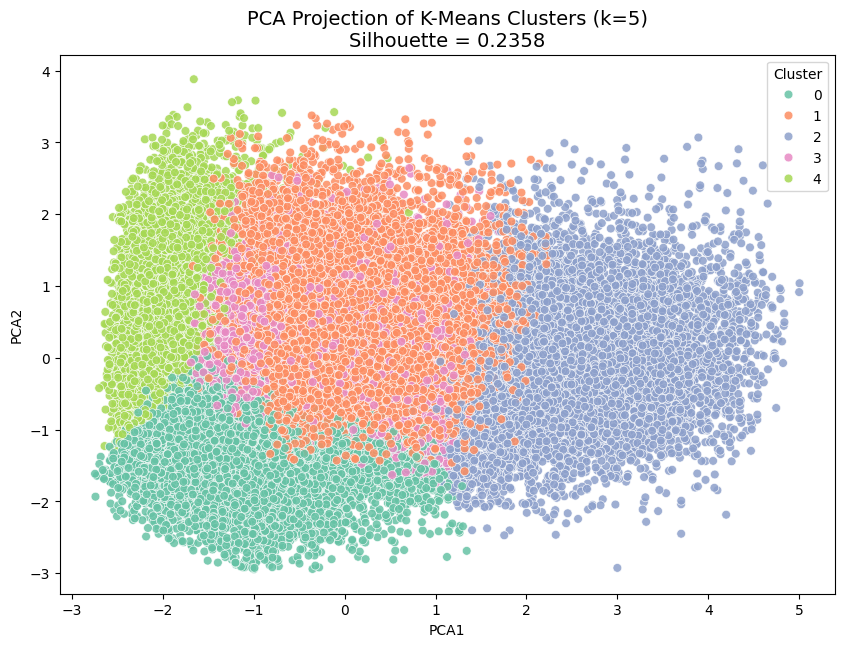

In [ ]:
k_final = 5
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df_lrfmc)

df_results = df_lrfmc_no_outlier.copy()
df_results['cluster'] = cluster_labels

pca = PCA(n_components=2, random_state=42)
pca_comp = pca.fit_transform(scaled_df_lrfmc)

df_results['pca1'] = pca_comp[:, 0]
df_results['pca2'] = pca_comp[:, 1]

sil_score = silhouette_score(scaled_df_lrfmc, cluster_labels)
print(f"Silhouette Score (k=5): {sil_score:.4f}")

print("\nCluster Counts:")
display(df_results['cluster'].value_counts().sort_index())

print("\nCluster Means (LRFMC):")
display(df_results.groupby('cluster')[['l','r','f','m','c']].mean().T)

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_results,
    x='pca1', y='pca2',
    hue='cluster',
    palette='Set2',
    s=40, alpha=0.85, edgecolor='white'
)
plt.title(f"PCA Projection of K-Means Clusters (k=5)\nSilhouette = {sil_score:.4f}", fontsize=14)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title='Cluster')
plt.show()

### Feature Distribution

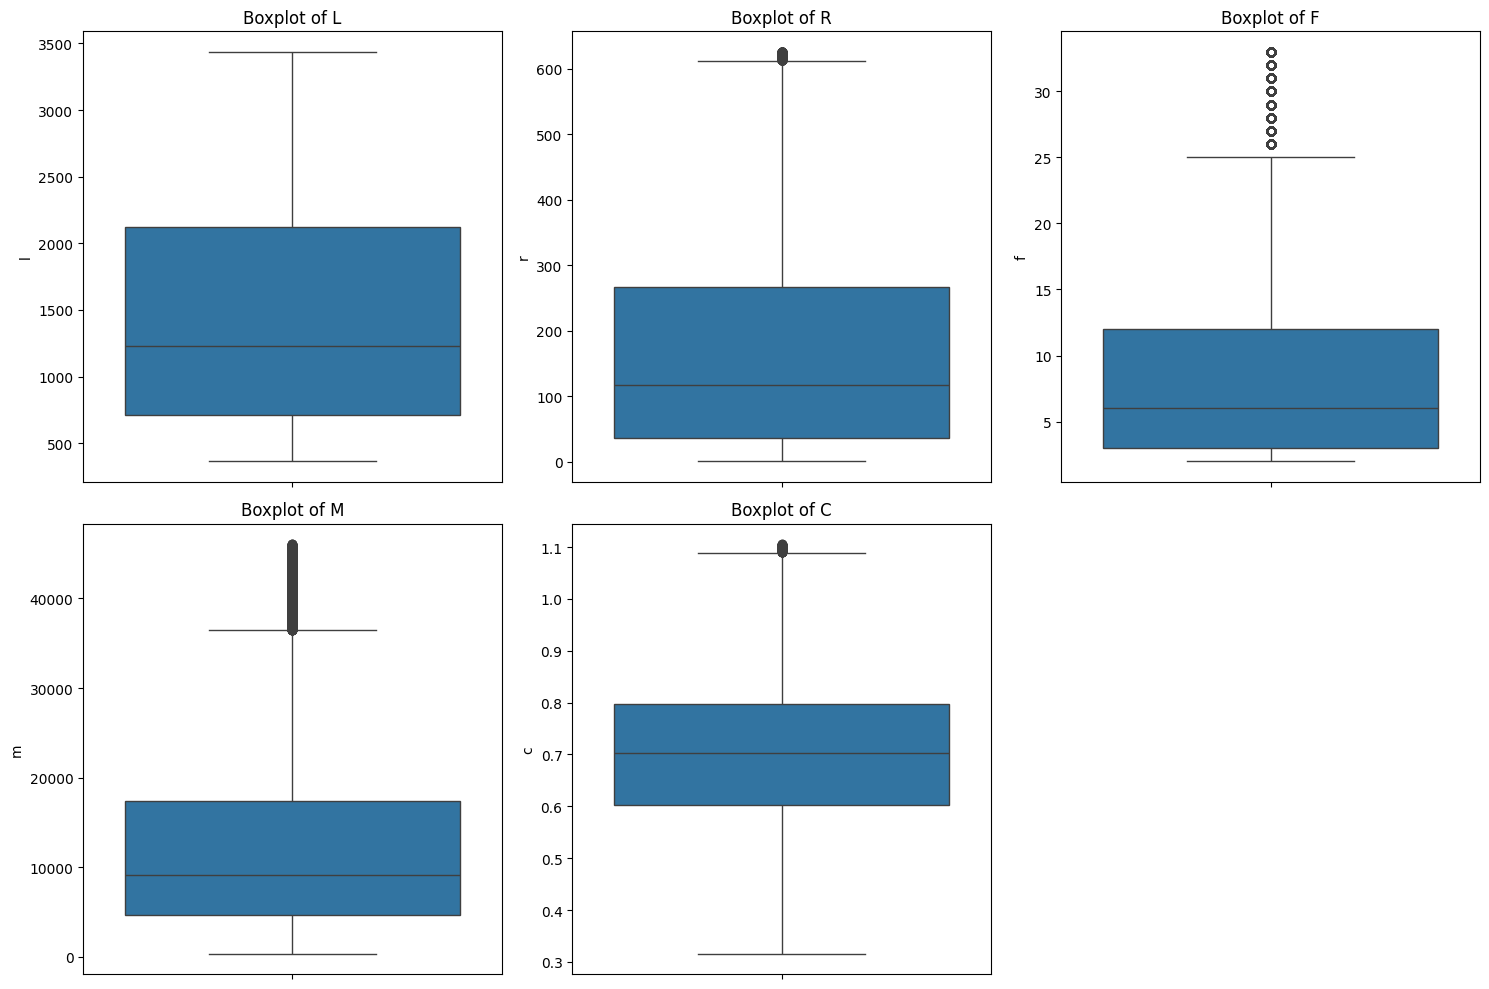

In [ ]:
features = ['l','r','f','m','c']

plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_results[col])
    plt.title(f'Boxplot of {col.upper()}')
plt.tight_layout()
plt.show()


In [ ]:
display(df_results.groupby('cluster')[['l','r','f','m','c']].mean())

,l,r,f,m,c
cluster,,,,,
0,1034.576550,199.852789,4.611260,7136.981302,0.508719
1,2515.786717,123.866248,7.064013,9992.528727,0.711702
2,1617.163164,61.913759,20.313640,28475.964116,0.713312
3,895.285060,102.864342,7.456296,10158.627246,0.765335
4,1250.265491,457.597702,3.847993,5686.483639,0.775470


In [ ]:
percentiles = df_results[['l','r','f','m','c']].quantile([0, 0.25, 0.5, 0.75, 1]).T
percentiles.columns = ['p0','p25','p50','p75','p100']

display(percentiles)

,p0,p25,p50,p75,p100
l,365.000000,709.000000,1228.000000,2126.000000,3437.000000
r,1.000000,37.000000,118.000000,267.000000,626.000000
f,2.000000,3.000000,6.000000,12.000000,33.000000
m,368.000000,4644.000000,9135.000000,17393.000000,46043.000000
c,0.315783,0.603212,0.702431,0.797625,1.105398


In [ ]:
cluster_means = df_results.groupby('cluster')[['l','r','f','m','c']].mean()
display(cluster_means)

,l,r,f,m,c
cluster,,,,,
0,1034.576550,199.852789,4.611260,7136.981302,0.508719
1,2515.786717,123.866248,7.064013,9992.528727,0.711702
2,1617.163164,61.913759,20.313640,28475.964116,0.713312
3,895.285060,102.864342,7.456296,10158.627246,0.765335
4,1250.265491,457.597702,3.847993,5686.483639,0.775470


In [ ]:
cluster_final = cluster_means.T.join(percentiles)
display(cluster_final)

,0,1,2,3,4,p0,p25,p50,p75,p100
l,1034.576550,2515.786717,1617.163164,895.285060,1250.265491,365.000000,709.000000,1228.000000,2126.000000,3437.000000
r,199.852789,123.866248,61.913759,102.864342,457.597702,1.000000,37.000000,118.000000,267.000000,626.000000
f,4.611260,7.064013,20.313640,7.456296,3.847993,2.000000,3.000000,6.000000,12.000000,33.000000
m,7136.981302,9992.528727,28475.964116,10158.627246,5686.483639,368.000000,4644.000000,9135.000000,17393.000000,46043.000000
c,0.508719,0.711702,0.713312,0.765335,0.775470,0.315783,0.603212,0.702431,0.797625,1.105398


In [ ]:
def categorize(value, p25, p50, p75):
    if value < p25:
        return 'Low'
    elif value < p50:
        return 'Mid-Low'
    elif value < p75:
        return 'Mid-High'
    else:
        return 'High'

categories = {}

for feature in ['l','r','f','m','c']:
    p25, p50, p75 = percentiles.loc[feature, ['p25','p50','p75']]
    categories[feature] = cluster_means[feature].apply(lambda x: categorize(x, p25, p50, p75))

display(pd.DataFrame(categories), cluster_means)


,l,r,f,m,c
cluster,,,,,
0,Mid-Low,Mid-High,Mid-Low,Mid-Low,Low
1,High,Mid-High,Mid-High,Mid-High,Mid-High
2,Mid-High,Mid-Low,High,High,Mid-High
3,Mid-Low,Mid-Low,Mid-High,Mid-High,Mid-High
4,Mid-High,High,Mid-Low,Mid-Low,Mid-High


,l,r,f,m,c
cluster,,,,,
0,1034.576550,199.852789,4.611260,7136.981302,0.508719
1,2515.786717,123.866248,7.064013,9992.528727,0.711702
2,1617.163164,61.913759,20.313640,28475.964116,0.713312
3,895.285060,102.864342,7.456296,10158.627246,0.765335
4,1250.265491,457.597702,3.847993,5686.483639,0.775470


# Cluster Insight and Business Recommendation

Cluster 0 — At Risk Low Value Flyers  

Karakteristik:
- L = Mid - Low
- R = Mid - High
- F = Mid- Low
- M = Mid - Low
- C = Low

Interpretasi:
Jenis pelanggan yang tidak loyal, Jarang terbang karena recency tinggi, Frekuensi terbang juga rendah, Monetary rendah, dan Jarang menggunakan Diskon

Rekomendasi Bisnis:  
- Kirim kampanye “We Miss You” atau promo comeback (voucher diskon, tiket murah).

- Fokus promo tiket pada rute pendek atau tiket low-cost untuk menarik mereka kembali.

- Hindari memberikan promo mahal karena segmen ini kontribusinya rendah.

- Gunakan push notification dan email reminder untuk re-engagement.

Cluster 1 — Loyal Mid Value Frequent Flyers

Karakteristik:
- L = High
- R = Mid - High
- F = Mid- High
- M = Mid - High
- C = Mid - High

Interpretasi: Jenis pelanggan yang sangat Loyal (L High), Terbang dalam waktu yg agak sedikit lama (Tidak baru-baru ini), namun Frekuensi terbang terbilang cukup tinggi, dan Monetary cukup tinggi, serta penggunaan Diskon cukup tinggi  

Rekomendasi Bisnis:  
- Berikan loyalty booster (bonus miles, upgrade kursi).

- Tawarkan add-on services (bagasi tambahan, seat selection premium).

- Berikan paket bundling hotel/travel untuk meningkatkan value.

- Berikan promo retensi agar tetap setia.

Cluster 2 — Elite High Frequency High Spender (VIP)

Karakteristik:
- L = Mid - High
- R = Mid - Low
- F = High
- M = High
- C = Mid - High

Interpretasi: Jenis Pelanggan yang cukup Loyal, Sering terbang baru-baru ini, Frequency terbang yang tinggi, dan cukup menyukai Promo (Discount)

Rekomendasi Bisnis:  
- Prioritaskan mereka dalam program VIP (lounge, priority boarding).

- Berikan penawaran eksklusif: rekomendasi rute premium, personal travel assistant.

- Tawarkan paket membership tahunan untuk menambah loyalitas jangka panjang.

- Fokus retensi agar mereka tidak berpindah ke maskapai lain.

Cluster 3 — Engaged Mid High - Spenders
Karakteristik:  
- L = Mid - Low
- R = Mid - Low
- F = Mid - High
- M = Mid - High
- C = Mid - High

Interpretasi: Jenis pelanggan yang tidak loyal, baru melakukan penerbangan akhir-akhir ini, sering melakukan penerbangan, Monetary cukup Tinggi, penggunaan Diskon cukup tinggi

Rekomendasi Bisnis:  
- Berikan program peningkatan poin loyalti.

- Berikan penawaran personal untuk meningkatkan frekuensi terbang.

- Arahkan mereka ke level membership yang lebih tinggi (gold/silver).

- Fokus pada retensi, karena nilai belanja sudah lumayan tinggi.

Cluster 4 — Recent Low-Freq Loyal /  Discount Seekers

Karakeristik:
- L = Mid - High
- R = High
- F = Mid - Low
- M = Mid - Low
- C = Mid - High

Interpretasi: Jenis pelanggan yang cukup Loyal, namun jarang terbang, dan sudah lama tidak melakukan penerbangan, Monetary rendah, cukup lumayan menggunakan Discount (C) Mid - High

Rekomendasi Bisnis:  

- Tawarkan promo untuk meningkatkan frekuensi (misalnya potongan harga rute tertentu).

- Arahkan cross-sell seperti bagasi, asuransi, atau seat upgrade.

- Berikan penawaran retensi agar mereka tetap aktif setelah penerbangan terakhir.

- Manfaatkan recency tinggi untuk kampanye follow-up (email pasca penerbangan).

# Reflection Questions

## Q1

Mengapa penting melakukan preprocessing dan EDA sebelum menerapkan algoritma clustering seperti K-Means? Jelaskan bagaimana langkah-langkah awal ini berpengaruh terhadap kualitas hasil clustering dan interpretasi cluster.


Jawaban:  
Preprocessing dan EDA penting karena memastikan data bersih, konsisten, dan berada pada skala yang tepat sebelum digunakan oleh K-Means yang sensitif terhadap outlier dan perbedaan skala. Tahapan seperti pembersihan data, pembuatan fitur LRFMC, serta visualisasi distribusi dan korelasi membantu memastikan bahwa fitur yang dipakai benar-benar relevan dan tidak bias. Hasilnya, cluster yang terbentuk menjadi lebih akurat, stabil, dan mudah diinterpretasikan secara bisnis.

## Q2


Bagaimana penggunaan metode clustering, seperti K-Means, dapat membantu pengambilan keputusan dalam konteks bisnis nyata? Berikan contoh bagaimana segmentasi pelanggan dapat digunakan untuk strategi pemasaran atau layanan yang lebih tepat sasaran.


Jawaban:  

Clustering seperti K-Means membantu bisnis memahami kelompok pelanggan berdasarkan pola perilaku, sehingga keputusan pemasaran dapat dibuat lebih tepat sasaran. Pada dataset flight.csv, segmentasi pelanggan memungkinkan perusahaan memberikan strategi berbeda, misalnya promo tiket jarak pendek untuk pelanggan hampir hilang, loyalty rewards (membership) untuk pelanggan bernilai tinggi, personalized promo,  dan promo peningkatan loyalitas untuk segmen menengah. Dengan segmentasi ini, perusahaan dapat meningkatkan retensi, meningkatkan pendapatan, dan mengoptimalkan alokasi biaya pemasaran.

# Summary

Dalam project ini dilakukan preprocessing, EDA, dan pemodelan K-Means untuk membentuk segmentasi pelanggan berbasis fitur LRFMC. Evaluasi menggunakan Silhouette Score dan analisis PCA menghasilkan konfigurasi 5 cluster yang paling stabil dan paling representatif. Setiap cluster memiliki karakteristik unik yang dimanfaatkan untuk menyusun rekomendasi bisnis seperti loyalty program, we've missed u campaign, cross-sell dan retensi pelanggan bernilai tinggi. Hasil segmentasi ini membantu perusahaan memahami perilaku pelanggan secara lebih terarah dan mendukung keputusan strategis yang lebih efektif